# 03 — Cross-subject results aggregation

Pulls all classification runs from `outputs/results/`, builds the cross-subject summary
table, and generates the plots that go into the GitHub README and any writeup.

**Models compared:** SVM (band-power features), EEGNet, CNN-BiLSTM
**Tasks:** N-class (per-subject), vowel/consonant, nasal/non-nasal, bilabial/non-bilabial

In [1]:
import sys, json
sys.path.insert(0, '..')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

from src.evaluate import load_runs, plot_confusion_matrix, plot_per_subject_accuracy

df = load_runs('../outputs/results')
print(f'Total runs: {len(df)}')
print(df.head())

Total runs: 75
                         run_id subject                    task  n_classes  \
0              phase3_test_MM05    MM05                11-class         11   
1              phase3_test_MM05    MM05        nasal_v_nonnasal          2   
2              phase3_test_MM05    MM05  bilabial_v_nonbilabial          2   
3              phase3_test_MM05    MM05       vowel_v_consonant          2   
4  phase3_batch_20260428_024033    MM05                11-class         11   

   mean_accuracy  std_accuracy  chance_level  f1_macro perm_pvalue  n_train  \
0       0.133333  3.090315e-02      0.090909  0.138397        None      660   
1       0.648485  3.090315e-02      0.500000  0.504248        None      660   
2       0.636364  1.916532e-02      0.500000  0.418468        None      660   
3       0.818182  1.110223e-16      0.500000  0.450000        None      660   
4       0.133333  3.090315e-02      0.090909  0.138397        None      660   

   n_test            timestamp  \
0     1

In [2]:
# Aggregate per-task statistics
agg = df.groupby('task').agg(
    n_subjects=('subject', 'nunique'),
    mean_acc=('mean_accuracy', 'mean'),
    median_acc=('mean_accuracy', 'median'),
    std_acc=('mean_accuracy', 'std'),
    min_acc=('mean_accuracy', 'min'),
    max_acc=('mean_accuracy', 'max'),
    chance=('chance_level', 'first'),
).round(3).sort_values('mean_acc', ascending=False)
print(agg)

                        n_subjects  mean_acc  median_acc  std_acc  min_acc  \
task                                                                         
vowel_v_consonant               13     0.682       0.661    0.088    0.558   
nasal_v_nonnasal                13     0.609       0.606    0.089    0.479   
bilabial_v_nonbilabial          13     0.607       0.609    0.071    0.485   
7-class_eegnet                   1     0.314       0.314      NaN    0.314   
7-class                          1     0.190       0.190      NaN    0.190   
11-class                        13     0.168       0.168    0.050    0.088   
11-class_eegnet                 13     0.164       0.158    0.034    0.106   

                        max_acc  chance  
task                                     
vowel_v_consonant         0.858   0.500  
nasal_v_nonnasal          0.798   0.500  
bilabial_v_nonbilabial    0.790   0.500  
7-class_eegnet            0.314   0.143  
7-class                   0.190   0.143  
11-

In [3]:
# Per-subject summary across tasks (wide format)
wide = df.pivot_table(
    index='subject', columns='task',
    values='mean_accuracy', aggfunc='first'
).round(3)
print(wide.fillna('—'))

task    11-class 11-class_eegnet 7-class 7-class_eegnet  \
subject                                                   
MM05       0.133           0.158       —              —   
MM08           —               —    0.19          0.314   
MM09       0.213           0.155       —              —   
MM10       0.229           0.148       —              —   
MM11       0.183           0.167       —              —   
MM12        0.24             0.2       —              —   
MM14       0.181           0.106       —              —   
MM15       0.217            0.25       —              —   
MM16       0.088           0.141       —              —   
MM18       0.122           0.178       —              —   
MM19       0.238           0.149       —              —   
MM20       0.117           0.142       —              —   
MM21        0.12           0.166       —              —   
P02        0.168           0.174       —              —   

task    bilabial_v_nonbilabial nasal_v_nonnasal vowel_v

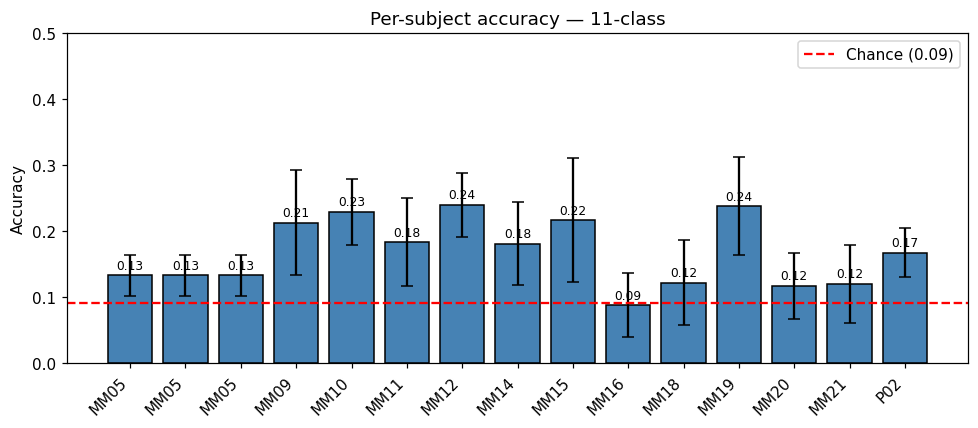

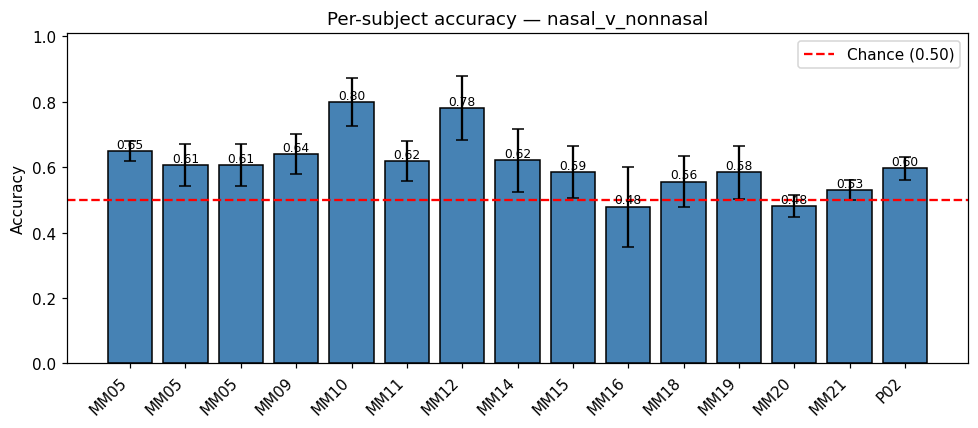

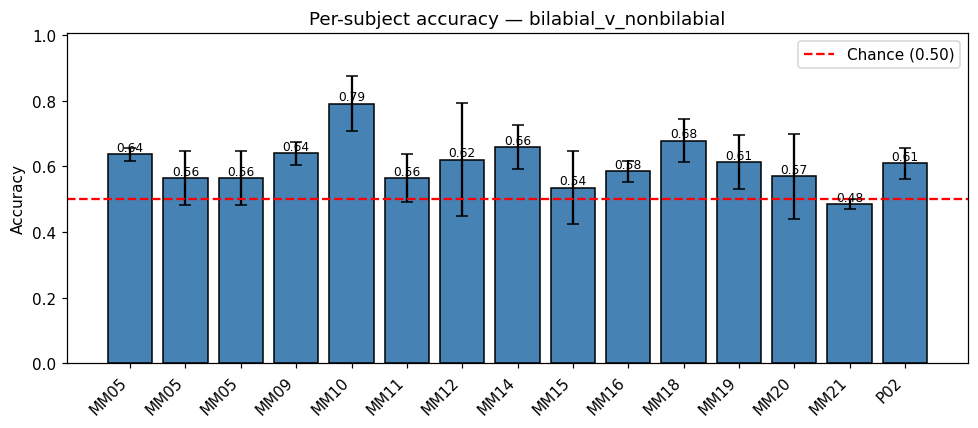

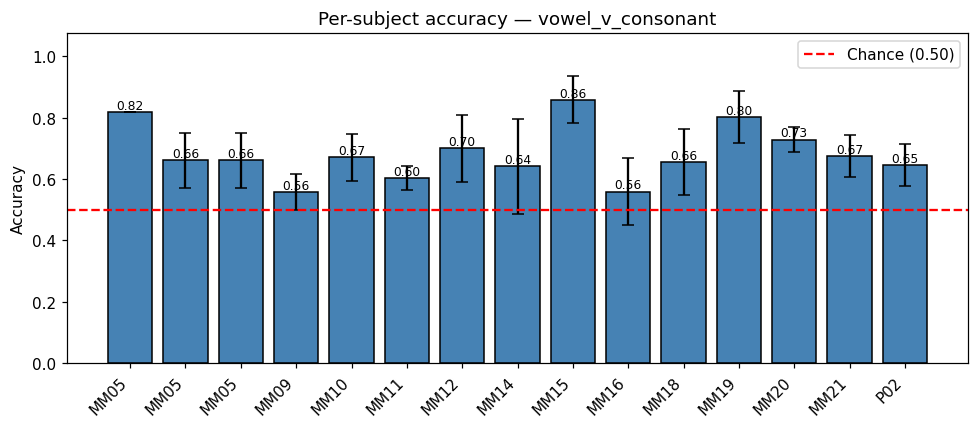

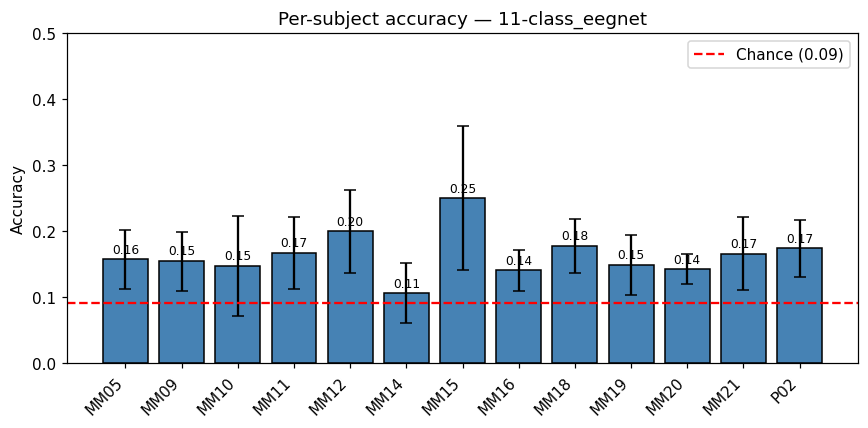

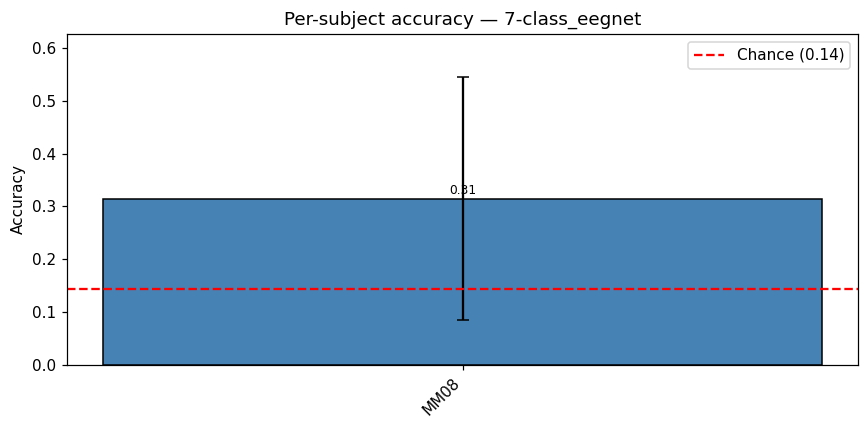

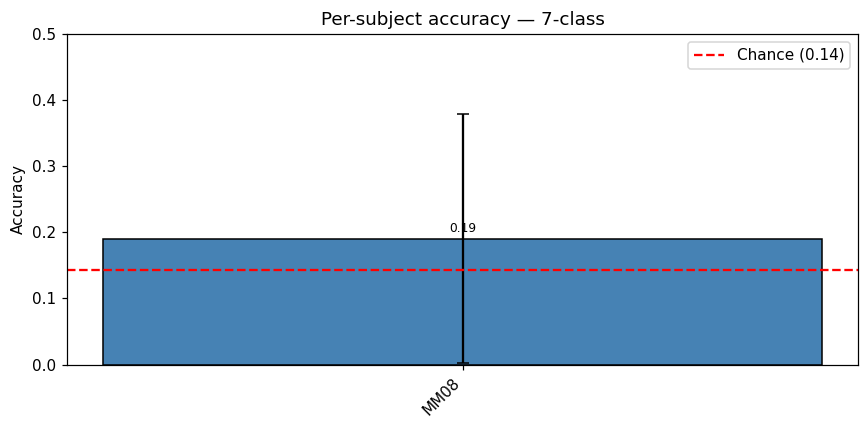

In [4]:
# Plot: per-subject accuracy on the main classification task
for task in df['task'].unique():
    fig = plot_per_subject_accuracy(
        df, task=task,
        save_path=f'../outputs/figures/per_subject_{task.replace("-","_")}.png',
    )
    if fig is not None:
        plt.show()

In [5]:
# Compare SVM vs EEGNet vs CNN-BiLSTM on the multi-class task
# (task names: '11-class' for SVM, '11-class_eegnet' for EEGNet, etc.)
model_results = []
for f in Path('../outputs/results').glob('**/*.json'):
    if f.name.startswith('_'):  # skip _batch_summary.json
        continue
    data = json.loads(f.read_text())
    task = data.get('task', '')
    # Heuristic: any task ending in _eegnet/_cnn_bilstm is a DL run
    if '_eegnet' in task:
        model = 'EEGNet'
    elif '_cnn_bilstm' in task or '_cnn-bilstm' in task:
        model = 'CNN-BiLSTM'
    elif task.endswith('-class'):
        model = 'SVM (band-power)'
    else:
        continue
    model_results.append({
        'subject': data['subject'],
        'model': model,
        'mean_acc': data['mean_accuracy'],
        'mean_bal': data.get('mean_balanced_accuracy'),
        'n_classes': data['n_classes'],
    })
model_df = pd.DataFrame(model_results)
if not model_df.empty:
    pivot = model_df.pivot_table(index='subject', columns='model', values='mean_acc', aggfunc='first').round(3)
    print(pivot.fillna('—'))

model    EEGNet  SVM (band-power)
subject                          
MM05      0.158             0.133
MM08      0.314             0.190
MM09      0.155             0.213
MM10      0.148             0.229
MM11      0.167             0.183
MM12      0.200             0.240
MM14      0.106             0.181
MM15      0.250             0.217
MM16      0.141             0.088
MM18      0.178             0.122
MM19      0.149             0.238
MM20      0.142             0.117
MM21      0.166             0.120
P02       0.174             0.168


Best run: MM15 on vowel_v_consonant = 0.858


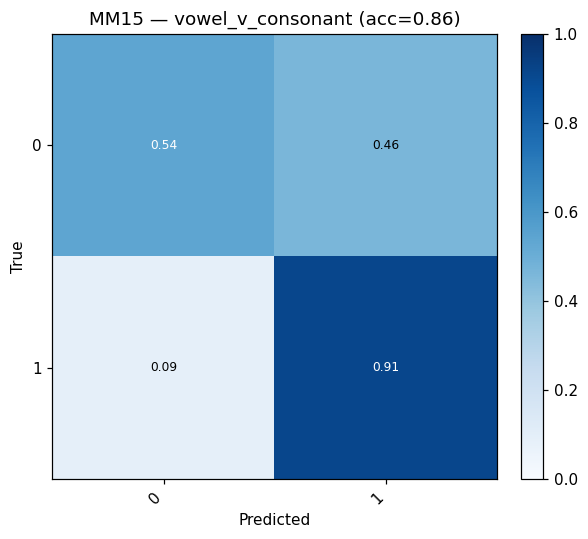

In [6]:
# Confusion matrix for the best subject (any task)
if not df.empty:
    best = df.sort_values('mean_accuracy', ascending=False).iloc[0]
    print(f'Best run: {best["subject"]} on {best["task"]} = {best["mean_accuracy"]:.3f}')
    payload = json.loads(Path(best['file']).read_text())
    fig = plot_confusion_matrix(
        payload['confusion_matrix'], payload['classes'],
        title=f'{best["subject"]} — {best["task"]} (acc={best["mean_accuracy"]:.2f})',
        save_path=f'../outputs/figures/best_confusion.png',
    )
    plt.show()

In [7]:
# Save the master summary CSV
csv_path = Path('../outputs/summary_results.csv')
df.to_csv(csv_path, index=False)
print(f'Saved {len(df)} rows to {csv_path}')

Saved 75 rows to ../outputs/summary_results.csv
